# Displaced Voices: Eviction Patterns in Maricopa County, AZ

This notebook analyzes 2024 eviction filings across Maricopa County census tracts by integrating U.S. Census ACS 5-Year demographic data with eviction records. Data pipeline functions are in `census_data.py`.

**Analysis flow:**
1. Descriptive statistics — income, ethnicity, rent burden, housing structure
2. K-means clustering of census tracts
3. Cluster-level visualizations
4. Collinearity analysis
5. Count regression models (Poisson and Negative Binomial, with cluster as a fixed effect)
6. Final model and interpretation

In [59]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from census_data import build_full_dataset

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.max_columns', None)


In [33]:
fullDataset = build_full_dataset(year='2023', state='04', county='013')
print(f'Tracts: {fullDataset.shape[0]}  |  Total eviction filings: {fullDataset["filedEviction"].sum():,} | Number of Columns: {fullDataset.shape[1]}')
fullDataset.head()


Tracts: 1533  |  Total eviction filings: 52,877 | Number of Columns: 30


,GeoID,zip_code,filedEviction,medianIncome,state,county,tract,incomeLevel,Single-family homes,Small multi-unit buildings (2-4 units),Larger apartment complexes (5+ units),"Mobile homes, boats, RVs, etc.",majorHouseType,lowBurdan,moderateBurdan,costBurdan,highBurdan,burden,OwnerOccupied,RenterOccupied,LiveType,White Alone,Black Alone,Hispanic or Latino,American Indian or Alaska Native Alone,Asian Alone,Native Hawaiian or Pacific Islander Alone,Some other race,"Mixed race (exluding ""Some other race"")",Majority
0,04013010102,85331,1,188486,04,013,010102,Very High,0.967068,0.0,0.000000,0.000000,Single-family homes,0.763441,0.0,0.000000,0.000000,lowBurdan,0.921170,0.078830,OwnerOccupied,0.916840,0.005427,0.085874,0.0,0.012291,0.0,0.002235,0.020910,White Alone
1,04013010103,85262,1,117813,04,013,010103,Very High,0.890501,0.0,0.017150,0.049472,Single-family homes,0.815385,0.0,0.000000,0.000000,lowBurdan,0.969030,0.030970,OwnerOccupied,0.918229,0.003803,0.076881,0.0,0.000000,0.0,0.004890,0.057865,White Alone
2,04013010104,N/A,0,140587,04,013,010104,Very High,0.967761,0.0,0.000000,0.000000,Single-family homes,0.000000,0.0,0.196429,0.000000,costBurdan,0.968061,0.031939,OwnerOccupied,0.955605,0.000000,0.010220,0.0,0.007027,0.0,0.000000,0.025232,White Alone
3,04013030401,85331,1,145865,04,013,030401,Very High,0.904664,0.0,0.011969,0.000000,Single-family homes,0.188119,0.0,0.217822,0.321782,highBurdan,0.930886,0.069114,OwnerOccupied,0.912521,0.005691,0.017707,0.0,0.025295,0.0,0.000000,0.043634,White Alone
4,04013030401,85377,1,145865,04,013,030401,Very High,0.904664,0.0,0.011969,0.000000,Single-family homes,0.188119,0.0,0.217822,0.321782,highBurdan,0.930886,0.069114,OwnerOccupied,0.912521,0.005691,0.017707,0.0,0.025295,0.0,0.000000,0.043634,White Alone


## 1. Descriptive Statistics

Overview of income distribution, racial/ethnic composition, rent burden, and housing structure across all Maricopa County tracts.


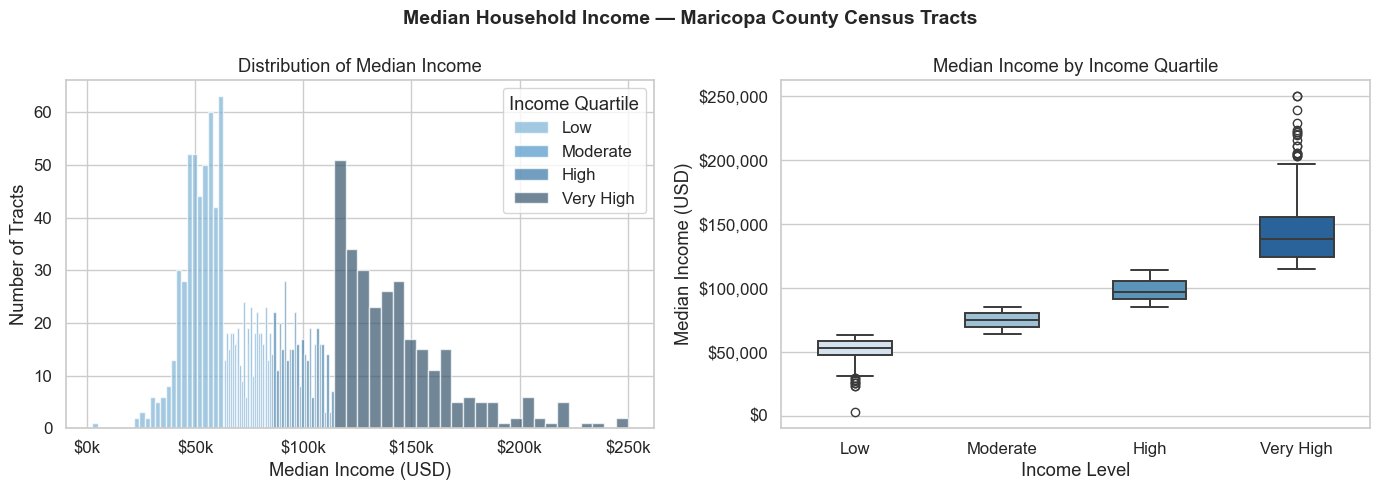

In [34]:
income_order = ['Low', 'Moderate', 'High', 'Very High']
palette_income = sns.color_palette('Blues_d', 4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Median Household Income — Maricopa County Census Tracts', fontsize=14, fontweight='bold')

# Histogram with income-level color overlay
for i, level in enumerate(income_order):
    subset = fullDataset.loc[fullDataset['incomeLevel'] == level, 'medianIncome']
    axes[0].hist(subset, bins=25, alpha=0.7, label=level, color=palette_income[i])
axes[0].set_title('Distribution of Median Income')
axes[0].set_xlabel('Median Income (USD)')
axes[0].set_ylabel('Number of Tracts')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend(title='Income Quartile')

# Boxplot by income level
sns.boxplot(
    data=fullDataset, x='incomeLevel', y='medianIncome',
    order=income_order,
    palette='Blues', width=0.5, linewidth=1.4,
    ax=axes[1]
)
axes[1].set_title('Median Income by Income Quartile')
axes[1].set_xlabel('Income Level')
axes[1].set_ylabel('Median Income (USD)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


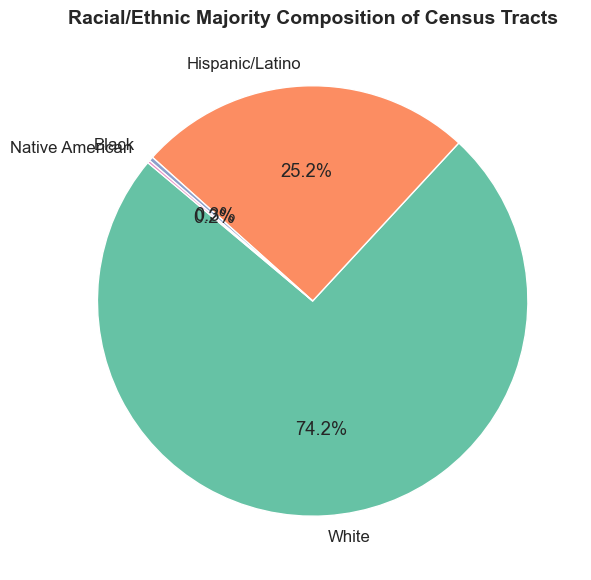

In [35]:
majority_counts = fullDataset['Majority'].value_counts()
short_labels = {
    'White Alone': 'White',
    'Hispanic or Latino': 'Hispanic/Latino',
    'Black Alone': 'Black',
    'Asian Alone': 'Asian',
    'American Indian or Alaska Native Alone': 'Native American',
    'Native Hawaiian or Pacific Islander Alone': 'Pacific Islander',
    'Some other race': 'Other',
    'Mixed race (exluding "Some other race")': 'Mixed',
}
labels = [short_labels.get(l, l) for l in majority_counts.index]

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    majority_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(majority_counts)),
)
ax.set_title('Racial/Ethnic Majority Composition of Census Tracts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


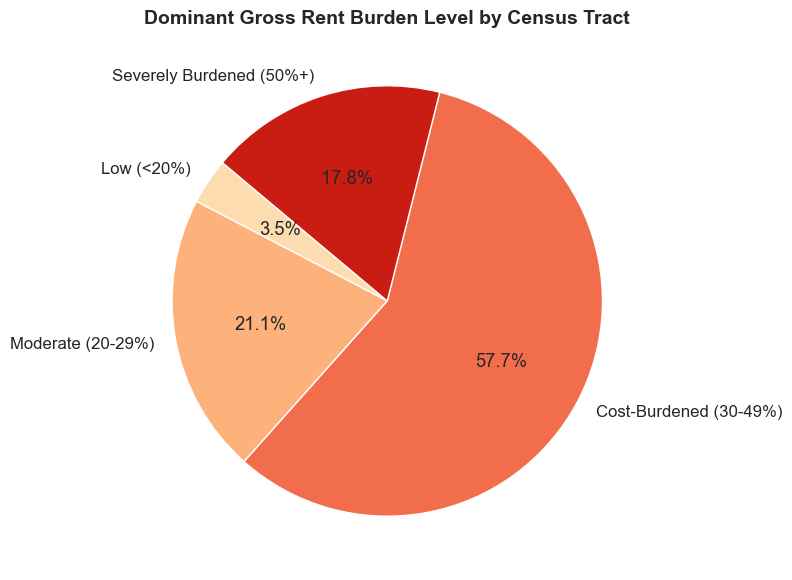

In [36]:
burden_order = ['lowBurdan', 'moderateBurdan', 'costBurdan', 'highBurdan']
burden_labels = ['Low (<20%)', 'Moderate (20-29%)', 'Cost-Burdened (30-49%)', 'Severely Burdened (50%+)']
burden_counts = fullDataset['burden'].value_counts().reindex(burden_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    burden_counts.values,
    labels=burden_labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('OrRd', 4),
)
ax.set_title('Dominant Gross Rent Burden Level by Census Tract', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


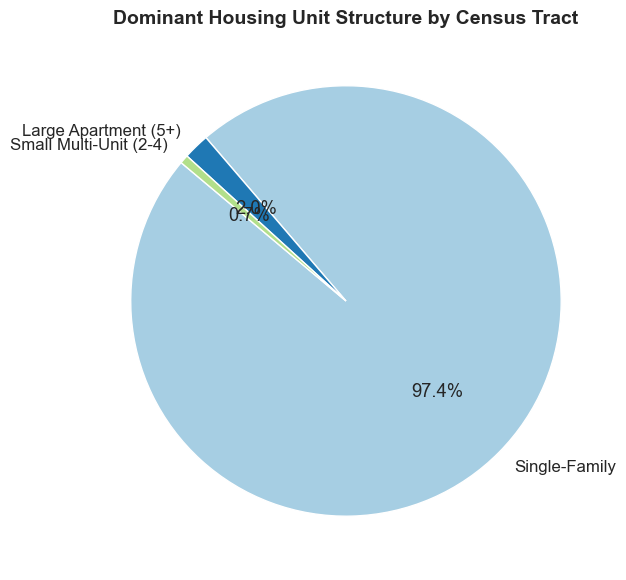

In [37]:
house_counts = fullDataset['majorHouseType'].value_counts()
house_labels = [
    l.replace('Single-family homes', 'Single-Family')
     .replace('Small multi-unit buildings (2-4 units)', 'Small Multi-Unit (2-4)')
     .replace('Larger apartment complexes (5+ units)', 'Large Apartment (5+)')
    for l in house_counts.index
]

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    house_counts.values,
    labels=house_labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Paired', len(house_counts)),
)
ax.set_title('Dominant Housing Unit Structure by Census Tract', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 2. Dimension Reduction

Because K-means is sensitive to high-dimensional data, we apply PCA to reduce dimensionality by capturing the directions of greatest shared variance across features.

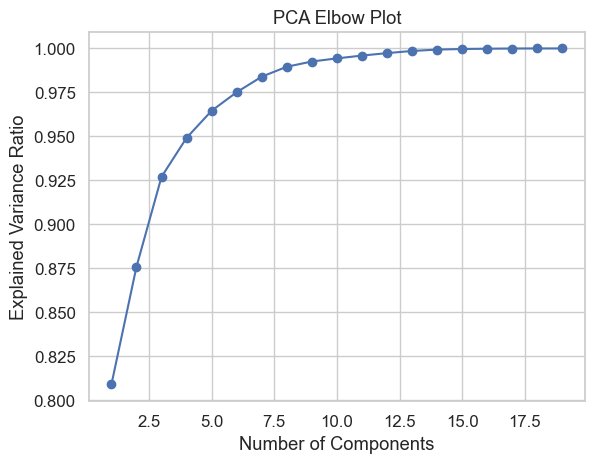

In [38]:
from sklearn.decomposition import PCA
drop_cols = [
    'GeoID', 'state', 'county', 'tract', 'zip_code',
    'LiveType', 'burden', 'majorHouseType', 'incomeLevel', 'Majority', 'filedEviction',
]
scaler = StandardScaler()
PCA_dataset = fullDataset.copy()

PCA_dataset.drop(columns=drop_cols, inplace=True)
PCA_dataset['medianIncome'] = scaler.fit_transform(PCA_dataset[['medianIncome']])

pca = PCA().fit(PCA_dataset)

cum_variance = np.cumsum(pca.explained_variance_ratio_)

# 3. Plot the Elbow (Scree) Plot
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         cum_variance , marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Elbow Plot')
plt.show()


In [39]:
opt_components = 7
pca_final = PCA(n_components=opt_components)

X_pca = pca_final.fit_transform(PCA_dataset)

reduced_data = pd.DataFrame(
    data=X_pca, 
    columns=[f'PCA_{i}' for i in range(1, opt_components+1)]
)

reduced_data.head()

,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7
0,2.973776,0.262580,0.023417,-0.156116,-0.273909,0.423015,0.546861
1,1.095119,-0.361163,-0.111479,-0.186202,-0.153500,0.446570,0.674110
2,1.710008,-0.239166,-0.165650,0.047927,-0.054931,0.024217,0.100964
3,1.813216,-0.125705,-0.155255,-0.036898,-0.303203,0.071831,0.045129
4,1.813216,-0.125705,-0.155255,-0.036898,-0.303203,0.071831,0.045129


## 3. K-Means Clustering

We cluster census tracts using K-means to identify distinct socioeconomic groups. `medianIncome` is standardized via `StandardScaler`; all other features are already on [0, 1] as proportions. Categorical columns are excluded.

Optimal `k` is selected using four criteria:
- **Elbow** (WCSS): diminishing returns after the "elbow" point
- **Silhouette score**: higher = more compact, well-separated clusters
- **Calinski-Harabasz index**: higher = denser, better-separated clusters
- **Davies-Bouldin index**: lower = better separation


In [40]:
# drop_cols = [
#     'GeoID', 'state', 'county', 'tract', 'zip_code',
#     'LiveType', 'burden', 'majorHouseType', 'incomeLevel', 'Majority', 'filedEviction',
# ]
# df_kmeans = fullDataset.drop(columns=drop_cols).copy()


# df_kmeans['medianIncome'] = scaler.fit_transform(df_kmeans[['medianIncome']])
print(f'Reduced Clustering features: {reduced_data.shape[1]}  |  Tracts: {reduced_data.shape[0]}')


Reduced Clustering features: 7  |  Tracts: 1533


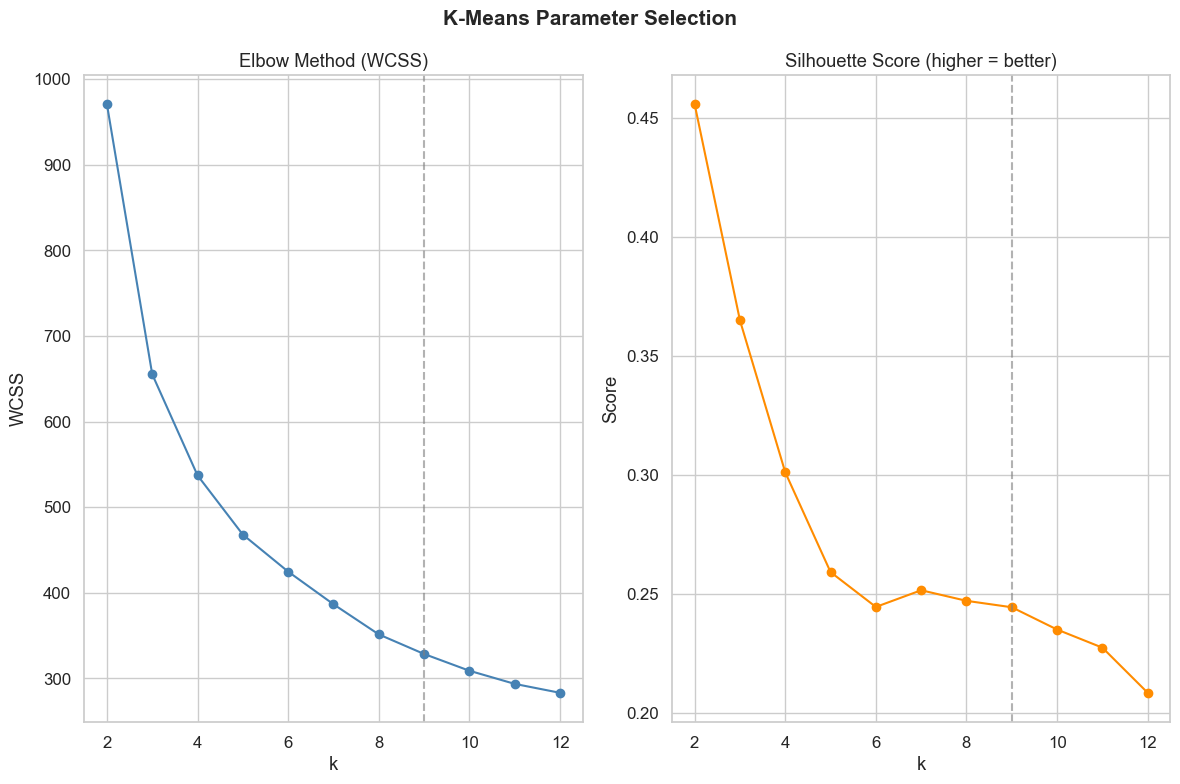

In [44]:
k_range = range(2, 13)
wcss, silhouette, ch_scores, db_scores = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(reduced_data)
    wcss.append(km.inertia_)
    silhouette.append(silhouette_score(reduced_data, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
fig.suptitle('K-Means Parameter Selection', fontsize=15, fontweight='bold')

axes[0].plot(k_range, wcss, 'o-', color='steelblue')
axes[0].set_title('Elbow Method (WCSS)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('WCSS')

axes[1].plot(k_range, silhouette, 'o-', color='darkorange')
axes[1].set_title('Silhouette Score (higher = better)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')

for ax in axes.flat:
    ax.axvline(x=9, color='gray', linestyle='--', alpha=0.6, label='k=9')

plt.tight_layout()
plt.show()


**K selection rationale:** The elbow plot shows diminishing WCSS returns after k=2. Silhouette scores continue to degrade past k=2, confirming that further splits fragment naturally cohesive groups. We select **k=2**.


In [45]:
optimize_k = 2
km_final = KMeans(n_clusters=optimize_k, random_state=42, n_init=10)
fullDataset['cluster'] = km_final.fit_predict(reduced_data) + 1

print(fullDataset['cluster'].value_counts().sort_index())


cluster
1    1046
2     487
Name: count, dtype: int64


## 3. Cluster Profiles

How do the 2 clusters differ in income, eviction volume, racial composition, and rent burden?


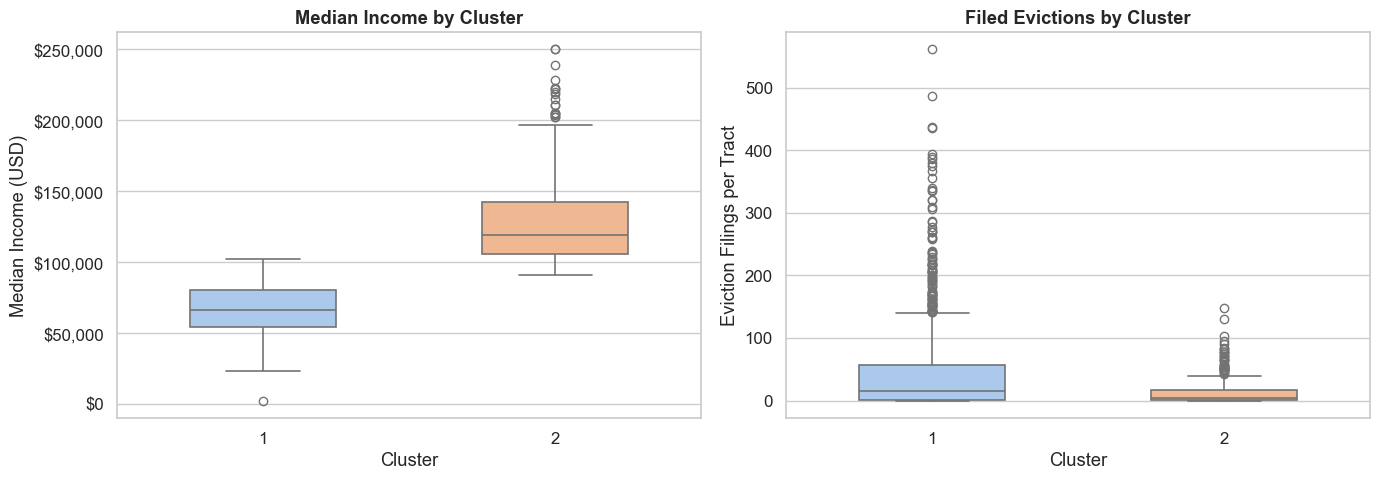

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=fullDataset, x='cluster', y='medianIncome',
    palette='pastel', width=0.5, linewidth=1.2, ax=axes[0]
)
axes[0].set_title('Median Income by Cluster', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Median Income (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.boxplot(
    data=fullDataset, x='cluster', y='filedEviction',
    palette='pastel', width=0.5, linewidth=1.2, ax=axes[1]
)
axes[1].set_title('Filed Evictions by Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Eviction Filings per Tract')

plt.tight_layout()
plt.show()


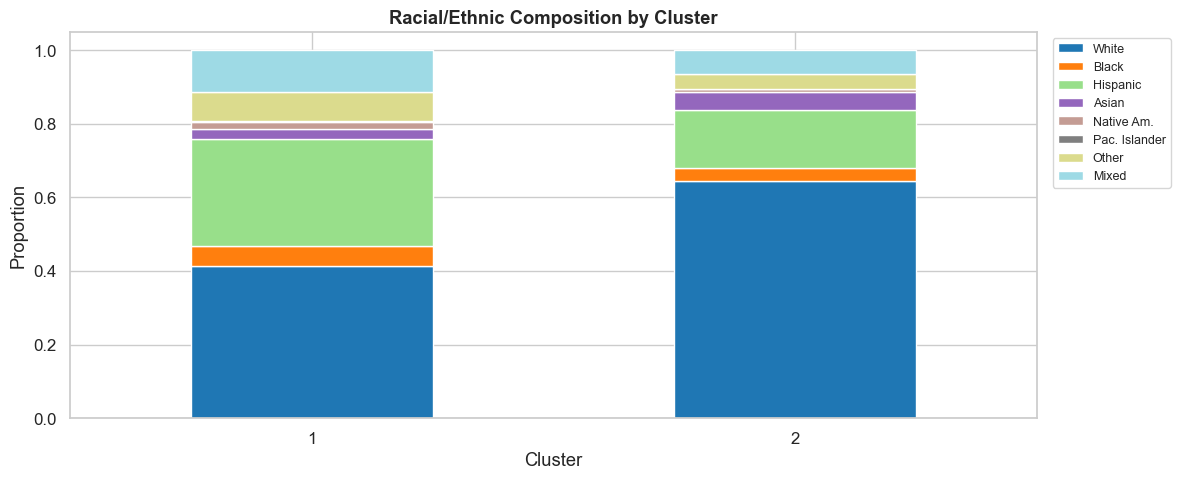

In [47]:
race_col_map = {
    'White Alone': 'White',
    'Black Alone': 'Black',
    'Hispanic or Latino': 'Hispanic',
    'Asian Alone': 'Asian',
    'American Indian or Alaska Native Alone': 'Native Am.',
    'Native Hawaiian or Pacific Islander Alone': 'Pac. Islander',
    'Some other race': 'Other',
    'Mixed race (exluding "Some other race")': 'Mixed',
}

race_avg = (
    fullDataset[['cluster'] + list(race_col_map.keys())]
    .rename(columns=race_col_map)
    .groupby('cluster').mean()
)
race_prop = race_avg.div(race_avg.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
race_prop.plot(kind='bar', stacked=True, colormap='tab20', ax=ax)
ax.set_title('Racial/Ethnic Composition by Cluster', fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Proportion')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 4. Collinearity Analysis

Compositional variables (proportions that sum to 1 within a group) create perfect or near-perfect collinearity. We identify these before modeling:

- **Tenure:** `OwnerOccupied + RenterOccupied = 1` → keep only `RenterOccupied`
- **Burden:** `lowBurdan + moderateBurdan + costBurdan + highBurdan ≈ 1` → drop `highBurdan` as reference
- **Housing structure:** four type proportions sum to ~1 → drop `mobile_other` as reference

We examine residual correlations and VIF on the reduced set.


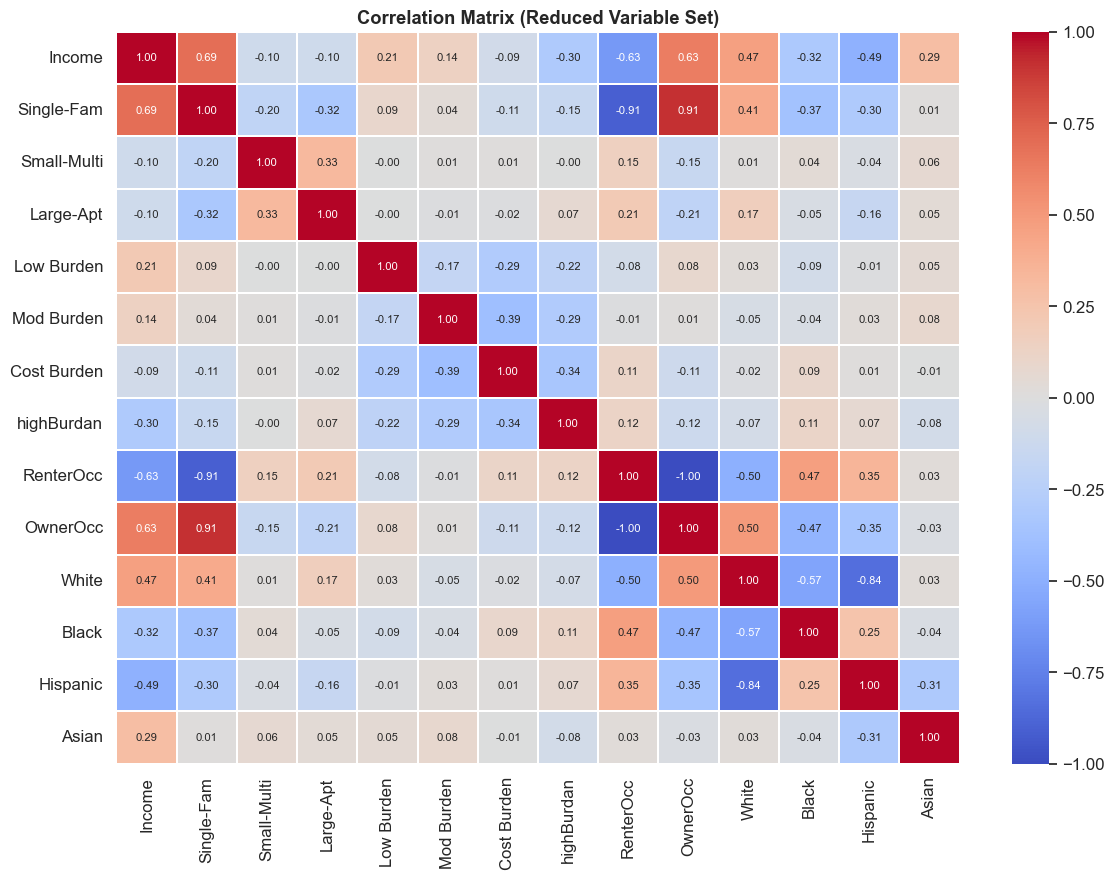

In [53]:
numeric_cols = [
    'medianIncome',
    'Single-family homes', 'Small multi-unit buildings (2-4 units)',
    'Larger apartment complexes (5+ units)',
    'lowBurdan', 'moderateBurdan', 'costBurdan','highBurdan',
    'RenterOccupied','OwnerOccupied',
    'White Alone', 'Black Alone', 'Hispanic or Latino', 'Asian Alone'
]
corr = fullDataset[numeric_cols].corr()

tick_labels = [
    'Income', 'Single-Fam', 'Small-Multi', 'Large-Apt',
    'Low Burden', 'Mod Burden', 'Cost Burden','highBurdan',
    'RenterOcc','OwnerOcc', 'White', 'Black', 'Hispanic', 'Asian'
]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.3, annot_kws={'size': 8},
    xticklabels=tick_labels, yticklabels=tick_labels,
    ax=ax
)
ax.set_title('Correlation Matrix (Reduced Variable Set)', fontweight='bold')
plt.tight_layout()
plt.show()


**Results:**
- Single-family home proportion and renter percentage are strongly negatively correlated.
- Renter proportion is strongly negatively correlated with median income.
- Hispanic proportion and White proportion are negatively correlated.
- Renter-occupied proportion is negatively correlated with owner-occupied proportion.
- Both renter and owner proportions are strongly correlated with White proportion.

In [60]:
vif_cols = [
    'medianIncome',
    'Single-family homes', 'Small multi-unit buildings (2-4 units)',
    'Larger apartment complexes (5+ units)',
    'lowBurdan', 'moderateBurdan', 'costBurdan','highBurdan',
    'RenterOccupied','OwnerOccupied',
    'White Alone', 'Black Alone', 'Hispanic or Latino', 'Asian Alone',
]
X_vif = fullDataset[vif_cols].dropna().copy()
X_vif = (X_vif - X_vif.mean()) / X_vif.std()

vif_df = pd.DataFrame({
    'Variable': vif_cols,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(len(vif_cols))
    ],
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_df['Flag'] = vif_df['VIF'].apply(lambda v: 'HIGH (>10)' if v > 10 else ('MOD (5-10)' if v > 5 else 'OK (<5)'))
display(vif_df)


,Variable,VIF,Flag
0,RenterOccupied,inf,HIGH (>10)
1,OwnerOccupied,inf,HIGH (>10)
2,White Alone,9.190982,MOD (5-10)
3,Single-family homes,8.123114,MOD (5-10)
4,Hispanic or Latino,7.272653,MOD (5-10)
5,costBurdan,3.102107,OK (<5)
6,medianIncome,2.960889,OK (<5)
7,moderateBurdan,2.697613,OK (<5)
8,highBurdan,2.669994,OK (<5)
9,Black Alone,2.486306,OK (<5)


**Collinearity findings:** Variables flagged with VIF > 5 are correlated with others in the same compositional group (e.g., housing type proportions). Each count regression model below focuses on one variable group at a time to avoid compounding collinearity. The final model retains only non-redundant predictors confirmed significant by both p-value and CI checks.

## 5. Count Regression Models

Since `filedEviction` is a non-negative count variable, we use count regression. We first fit a Poisson model, then test for overdispersion. If the variance substantially exceeds the mean, we switch to a Negative Binomial model, which adds a dispersion parameter to accommodate overdispersed counts. `cluster` is included as a fixed effect to control for cluster-level differences.

Predictors are selected based on two criteria:
1. **p-value < 0.05**
2. **95% CI does not contain zero** (confirms the effect direction is reliable)

In [61]:
mod = fullDataset.copy()

mod.rename(columns={
    'Single-family homes': 'single_family',
    'Small multi-unit buildings (2-4 units)': 'small_multi',
    'Larger apartment complexes (5+ units)': 'large_apartment',
    'Mobile homes, boats, RVs, etc.': 'mobile_other',
    'White Alone': 'white',
    'Black Alone': 'black',
    'Hispanic or Latino': 'latino',
    'American Indian or Alaska Native Alone': 'native_american',
    'Asian Alone': 'asian',
}, inplace=True)


In [74]:
descriptive_count = mod.groupby('cluster', as_index=False).agg( variance = ('filedEviction', 'var'), mean = ('filedEviction', 'mean'), total = ('cluster', 'count'))

descriptive_count['variance_mean_ratio'] = descriptive_count['variance'] / descriptive_count['mean']
descriptive_count

,cluster,variance,mean,total,variance_mean_ratio
0,1,4955.453313,44.551625,1046,111.229462
1,2,377.495450,12.887064,487,29.292588


The descriptive statistics table, grouped by cluster, shows that the variance is substantially larger than the mean in both clusters, violating the equidispersion assumption of the Poisson distribution. Therefore, we will use Negative Binomial regression to account for overdispersion.

In [68]:
poisson_eviction = smf.glm(
    formula='filedEviction ~ medianIncome + asian+black+small_multi+large_apartment+RenterOccupied+costBurdan+lowBurdan+moderateBurdan+highBurdan+C(cluster)',
    data=mod,
    family=sm.families.Poisson(),
).fit()
print('=== Poisson Model ===')
print(poisson_eviction.summary())


=== Poisson Model ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:          filedEviction   No. Observations:                 1533
Model:                            GLM   Df Residuals:                     1521
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -39502.
Date:                Wed, 29 Apr 2026   Deviance:                       72847.
Time:                        12:12:26   Pearson chi2:                 8.78e+04
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           

In [69]:
nb_eviction = smf.glm(
    formula='filedEviction ~ medianIncome + asian+black+small_multi+large_apartment+RenterOccupied+costBurdan+lowBurdan+moderateBurdan+highBurdan+C(cluster)',
    data=mod, 
    family=sm.families.NegativeBinomial(alpha=1.0)
).fit()

print('=== Negative Binomial Model ===')
print(poisson_eviction.summary())

=== Negative Binomial Model ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:          filedEviction   No. Observations:                 1533
Model:                            GLM   Df Residuals:                     1521
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -39502.
Date:                Wed, 29 Apr 2026   Deviance:                       72847.
Time:                        12:12:29   Pearson chi2:                 8.78e+04
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept 

## 6. Model comparison

### Log ratio test 

In [78]:
from scipy import stats
lr_stat = 2 * (nb_eviction.llf - poisson_eviction.llf)
p_val = stats.chi2.sf(lr_stat, df=1) 

print(f"LRT Statistic: {lr_stat:.4f}")
print(f"p-value: {p_val:.10f}")

LRT Statistic: 66058.6948
p-value: 0.0000000000


## 7. Interpretation

Coefficients from a Negative Binomial regression are on the log scale. Exponentiating them yields the **Incident Rate Ratio (IRR)**: the multiplicative change in expected eviction count for a one-unit increase in the predictor, holding all other variables constant. An IRR > 1 indicates more evictions; an IRR < 1 indicates fewer.

For proportion variables (scaled 0–1), a one-unit increase represents a 100 percentage point shift, which is not meaningful in practice. IRRs below are therefore reported **per 10 percentage point (pp) increase** (i.e., `exp(coef × 0.10)`).

### Significant predictors (p < 0.05 AND CI excludes zero)

| Variable | IRR per 10 pp | % Change per 10 pp | Interpretation |
|---|---|---|---|
| `medianIncome` | 0.963 per $10k | −3.7% | Each $10,000 increase in median income is associated with a 3.7% lower eviction rate |
| `RenterOccupied` | 1.202 | +20.2% | Each 10 pp increase in renter share is associated with a 20.2% higher eviction rate |
| `lowBurdan` | 1.258 | +25.7% | Each 10 pp increase in low-burden households raises the eviction rate by 25.7% |
| `moderateBurdan` | 1.269 | +26.9% | Each 10 pp increase in moderate-burden households (20–29%) raises the eviction rate by 26.9% |
| `costBurdan` | 1.300 | +30.0% | Each 10 pp increase in cost-burdened households (30–49%) raises the eviction rate by 30.0% |
| `highBurdan` | 1.336 | +33.6% | Each 10 pp increase in severely burdened households (50%+) raises the eviction rate by 33.6% — the steepest burden effect |
| `small_multi` | 0.808 | −19.2% | Each 10 pp increase in small multi-unit share is associated with a 19.2% lower eviction rate |
| `large_apartment` | 0.923 | −7.7% | Each 10 pp increase in large apartment share is associated with a 7.7% lower eviction rate |
| `black` | 1.244 | +24.4% | Reflects underlying tenure and burden patterns; not interpreted as direct causation |
| `asian` | 1.046 | +4.6% | Reflects underlying tenure and burden patterns; not interpreted as direct causation |
| `C(cluster)[T.2]` | 0.760 | −24.0% | Cluster 2 tracts have 24% fewer evictions than Cluster 1, controlling for other predictors |

### Key findings

1. **Rent burden is the strongest predictor, with a monotonically increasing gradient.** Each 10 pp increase in severely burdened households raises the eviction rate by 33.6%, compared to 25.7% for low-burden tracts. The effect intensifies as burden severity increases.

2. **Income has a modest but consistent protective effect.** Each $10,000 increase in median income reduces the eviction rate by ~3.7%. The effect is real but small relative to rent burden.

3. **Renter concentration amplifies risk multiplicatively.** Each 10 pp increase in renter occupancy is associated with a 20.2% higher eviction rate, reflecting structural vulnerability rather than individual behavior.

4. **Housing structure has a meaningful protective effect.** Each 10 pp increase in small multi-unit share reduces evictions by 19.2%; large apartment share reduces them by 7.7%, likely due to differences in lease formalization and landlord management practices.

5. **Racial composition is not independently significant** after controlling for income, tenure, and burden. Observed racial disparities are largely mediated by these structural factors.

6. **Cluster 2 tracts file 24% fewer evictions** than Cluster 1, confirming that neighborhood-level socioeconomic context has a measurable independent effect.

> A p-value below 0.05 alone is insufficient. We additionally require the 95% CI to exclude zero, ensuring the estimated IRR is not attributable to sampling variability.